# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python

**Student Name:** Pranavi Balakulla  
**Course:** MSCS 634  
**Lab Assignment:** Lab 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the retail sales dataset
df = pd.read_csv("retail_sales_data.csv", parse_dates=["Date"])

# Display the first five rows
df.head()

,Transaction_ID,Date,Category,Region,Store,Quantity,Discount_Percent,Sales,Customer_Rating
0,TX1001,2025-01-01,Grocery,East,Online,3,25,32.83,3.2
1,TX1002,2025-01-02,Home,North,Store A,9,0,790.85,3.9
2,TX1003,2025-01-03,Clothing,North,Online,2,5,75.57,2.6
3,TX1004,2025-01-04,Beauty,South,Online,5,15,138.07,4.1
4,TX1005,2025-01-05,Beauty,West,Online,5,0,131.33,4.3


## Step 2: Data Visualization

### 2.1 Scatter Plot: Quantity vs. Sales

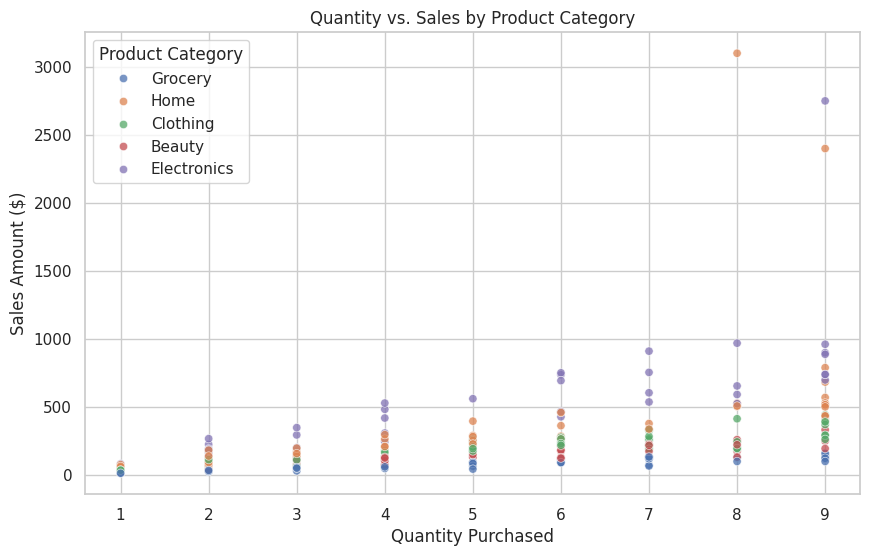

In [3]:
# Create a scatter plot to examine the relationship
# between quantity purchased and sales amount

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales",
    hue="Category",
    alpha=0.75
)

plt.title("Quantity vs. Sales by Product Category")
plt.xlabel("Quantity Purchased")
plt.ylabel("Sales Amount ($)")
plt.legend(title="Product Category")
plt.show()

**Scatter Plot Insight:**  
The scatter plot shows a generally positive relationship between quantity purchased and sales amount. Transactions with higher quantities usually produce higher sales. Electronics transactions tend to have higher sales values because electronics have higher unit prices. A few observations above $2,000 appear unusually high and may represent outliers that require further investigation.

### 2.2 Line Plot: Monthly Sales Trend

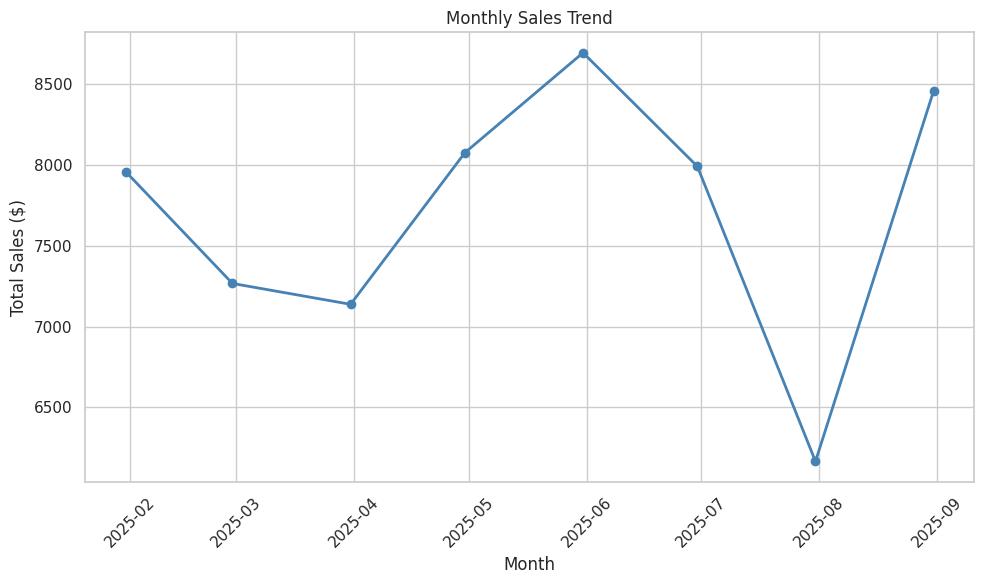

In [4]:
# Calculate total sales for each month
monthly_sales = (
    df.set_index("Date")["Sales"]
      .resample("ME")
      .sum()
)

# Create the monthly sales line plot
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Line Plot Insight:**  
Monthly sales fluctuate throughout the observed period. Sales decrease during the early months, increase to their highest level around May, and then decline sharply before recovering in the final month. These changes may be influenced by differences in transaction volume, product categories, quantities purchased, and unusually large sales transactions.

## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

The first preprocessing task is to detect missing values in the original dataset.

In [5]:
# Count missing values in every column
missing_before = df.isnull().sum()

print("Missing values before preprocessing:")
print(missing_before)

print("\nTotal missing values:", missing_before.sum())

Missing values before preprocessing:
Transaction_ID      0
Date                0
Category            0
Region              0
Store               0
Quantity            0
Discount_Percent    0
Sales               4
Customer_Rating     3
dtype: int64

Total missing values: 7


In [6]:
# Display all rows that contain at least one missing value
missing_rows = df[df.isnull().any(axis=1)]

print("Rows containing missing values:")
missing_rows

Rows containing missing values:


,Transaction_ID,Date,Category,Region,Store,Quantity,Discount_Percent,Sales,Customer_Rating
8,TX1009,2025-01-09,Grocery,West,Store A,7,10,140.72,NaN
12,TX1013,2025-01-13,Beauty,East,Store C,2,10,NaN,4.5
61,TX1062,2025-03-03,Clothing,South,Online,6,15,279.24,NaN
74,TX1075,2025-03-16,Beauty,East,Store B,1,0,NaN,3.6
151,TX1152,2025-06-01,Clothing,West,Store A,7,5,NaN,3.4
190,TX1191,2025-07-10,Grocery,East,Online,7,0,122.26,NaN
205,TX1206,2025-07-25,Clothing,West,Store A,9,10,NaN,4.2


In [7]:
# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

# Calculate replacement values
sales_median = df_clean["Sales"].median()
rating_mode = df_clean["Customer_Rating"].mode()[0]

print("Sales median used for replacement:", sales_median)
print("Customer rating mode used for replacement:", rating_mode)

# Replace missing values
df_clean["Sales"] = df_clean["Sales"].fillna(sales_median)
df_clean["Customer_Rating"] = (
    df_clean["Customer_Rating"].fillna(rating_mode)
)

# Count missing values after replacement
missing_after = df_clean.isnull().sum()

print("\nMissing values after preprocessing:")
print(missing_after)

print("\nTotal missing values after preprocessing:",
      missing_after.sum())

Sales median used for replacement: 175.09
Customer rating mode used for replacement: 4.2

Missing values after preprocessing:
Transaction_ID      0
Date                0
Category            0
Region              0
Store               0
Quantity            0
Discount_Percent    0
Sales               0
Customer_Rating     0
dtype: int64

Total missing values after preprocessing: 0


In [8]:
# Compare the affected rows before and after preprocessing
missing_comparison = pd.DataFrame({
    "Transaction_ID": df.loc[
        missing_rows.index, "Transaction_ID"
    ],
    "Sales_Before": df.loc[
        missing_rows.index, "Sales"
    ],
    "Sales_After": df_clean.loc[
        missing_rows.index, "Sales"
    ],
    "Rating_Before": df.loc[
        missing_rows.index, "Customer_Rating"
    ],
    "Rating_After": df_clean.loc[
        missing_rows.index, "Customer_Rating"
    ]
})

missing_comparison

,Transaction_ID,Sales_Before,Sales_After,Rating_Before,Rating_After
8,TX1009,140.72,140.72,NaN,4.2
12,TX1013,NaN,175.09,4.5,4.5
61,TX1062,279.24,279.24,NaN,4.2
74,TX1075,NaN,175.09,3.6,3.6
151,TX1152,NaN,175.09,3.4,3.4
190,TX1191,122.26,122.26,NaN,4.2
205,TX1206,NaN,175.09,4.2,4.2


**Missing-Value Treatment:**  
The original dataset contained four missing Sales values and three missing Customer_Rating values. Missing Sales values were replaced with the median of 175.09 because the median is less affected by extreme values. Missing Customer_Rating values were replaced with the mode of 4.2 because it represents the most frequently occurring rating. After preprocessing, the dataset contained no missing values.

### 3.2 Outlier Detection and Removal Using the IQR Method

The Interquartile Range method identifies Sales values that fall below the lower boundary or above the upper boundary.

In [9]:
# Calculate the first and third quartiles for Sales
Q1 = df_clean["Sales"].quantile(0.25)
Q3 = df_clean["Sales"].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate the lower and upper boundaries
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Boundary:", round(lower_bound, 2))
print("Upper Boundary:", round(upper_bound, 2))

# Identify outliers
outliers = df_clean[
    (df_clean["Sales"] < lower_bound) |
    (df_clean["Sales"] > upper_bound)
]

print("\nNumber of outliers identified:", len(outliers))

outliers[
    ["Transaction_ID", "Category", "Quantity", "Sales"]
]

Q1: 86.31
Q3: 288.38
IQR: 202.08
Lower Boundary: -216.8
Upper Boundary: 591.49

Number of outliers identified: 20


,Transaction_ID,Category,Quantity,Sales
1,TX1002,Home,9,790.85
10,TX1011,Electronics,7,606.21
19,TX1020,Electronics,9,962.90
30,TX1031,Electronics,7,912.11
33,TX1034,Home,9,2400.00
85,TX1086,Electronics,8,593.80
111,TX1112,Electronics,6,738.56
112,TX1113,Electronics,8,970.73
122,TX1123,Home,8,3100.00
144,TX1145,Home,9,685.04


In [10]:
# Remove Sales values outside the IQR boundaries
df_no_outliers = df_clean[
    (df_clean["Sales"] >= lower_bound) &
    (df_clean["Sales"] <= upper_bound)
].copy()

print("Dataset before outlier removal:", df_clean.shape)
print("Dataset after outlier removal:", df_no_outliers.shape)
print("Number of rows removed:",
      len(df_clean) - len(df_no_outliers))

print("\nMaximum Sales before removal:",
      df_clean["Sales"].max())

print("Maximum Sales after removal:",
      df_no_outliers["Sales"].max())

# Display the first five rows after outlier removal
df_no_outliers.head()

Dataset before outlier removal: (240, 9)
Dataset after outlier removal: (220, 9)
Number of rows removed: 20

Maximum Sales before removal: 3100.0
Maximum Sales after removal: 571.77


,Transaction_ID,Date,Category,Region,Store,Quantity,Discount_Percent,Sales,Customer_Rating
0,TX1001,2025-01-01,Grocery,East,Online,3,25,32.83,3.2
2,TX1003,2025-01-03,Clothing,North,Online,2,5,75.57,2.6
3,TX1004,2025-01-04,Beauty,South,Online,5,15,138.07,4.1
4,TX1005,2025-01-05,Beauty,West,Online,5,0,131.33,4.3
5,TX1006,2025-01-06,Home,East,Store A,5,5,250.53,3.7


**Outlier Treatment:**  
The IQR method identified 20 Sales values outside the calculated boundaries. These records were removed, reducing the dataset from 240 rows to 220 rows. The maximum Sales value decreased from $3,100.00 to $571.77 after outlier removal. The resulting dataset better represents typical retail transactions.

**Outlier Treatment:**  
The IQR method identified 20 Sales values outside the calculated boundaries. These records were removed, reducing the dataset from 240 rows to 220 rows. The maximum Sales value decreased from 3,100.00 dollars to 571.77 dollars after outlier removal. The resulting dataset better represents typical retail transactions.

### 3.3 Data Reduction

Data reduction is performed using a 25% random sample and by removing columns that are not required for the remaining statistical analysis.

In [11]:
# Display dataset information before reduction
print("BEFORE DATA REDUCTION")
print("Number of rows:", df_no_outliers.shape[0])
print("Number of columns:", df_no_outliers.shape[1])
print("Columns:", df_no_outliers.columns.tolist())

# Select a reproducible 25% random sample
reduced_df = df_no_outliers.sample(
    frac=0.25,
    random_state=42
)

# Remove less-relevant columns
reduced_df = reduced_df.drop(
    columns=["Transaction_ID", "Store"]
)

# Display dataset information after reduction
print("\nAFTER DATA REDUCTION")
print("Number of rows:", reduced_df.shape[0])
print("Number of columns:", reduced_df.shape[1])
print("Columns:", reduced_df.columns.tolist())

reduced_df.head()

BEFORE DATA REDUCTION
Number of rows: 220
Number of columns: 9
Columns: ['Transaction_ID', 'Date', 'Category', 'Region', 'Store', 'Quantity', 'Discount_Percent', 'Sales', 'Customer_Rating']

AFTER DATA REDUCTION
Number of rows: 55
Number of columns: 7
Columns: ['Date', 'Category', 'Region', 'Quantity', 'Discount_Percent', 'Sales', 'Customer_Rating']


,Date,Category,Region,Quantity,Discount_Percent,Sales,Customer_Rating
141,2025-05-22,Beauty,South,2,20,73.96,4.2
161,2025-06-11,Clothing,East,7,20,192.12,4.3
99,2025-04-10,Home,South,9,15,516.66,3.4
196,2025-07-16,Clothing,South,9,10,264.42,3.7
17,2025-01-18,Beauty,South,2,25,34.38,3.3


**Data-Reduction Result:**  
The cleaned dataset originally contained 220 rows and 9 columns. A reproducible 25% random sample reduced the dataset to 55 rows. The Transaction_ID and Store columns were also removed because they were not required for the remaining statistical analysis. After row sampling and dimension elimination, the reduced dataset contained 55 rows and 7 columns.

### 3.4 Data Scaling and Discretization

Min-Max scaling transforms numerical values to a range between 0 and 1. Discretization converts the continuous Sales values into meaningful categories.

In [12]:
# Create a copy of the dataset after outlier removal
scaled_df = df_no_outliers.copy()

# Apply Min-Max scaling
scaler = MinMaxScaler()

columns_to_scale = ["Sales", "Quantity", "Discount_Percent"]
scaled_columns = [
    "Sales_Scaled",
    "Quantity_Scaled",
    "Discount_Percent_Scaled"
]

scaled_df[scaled_columns] = scaler.fit_transform(
    scaled_df[columns_to_scale]
)

# Discretize Sales into categories
scaled_df["Sales_Level"] = pd.cut(
    scaled_df["Sales"],
    bins=[-np.inf, 150, 400, np.inf],
    labels=["Low", "Medium", "High"]
)

# Display original and transformed values
scaling_comparison = scaled_df[
    [
        "Sales",
        "Sales_Scaled",
        "Quantity",
        "Quantity_Scaled",
        "Discount_Percent",
        "Discount_Percent_Scaled",
        "Sales_Level"
    ]
].head(10)

scaling_comparison

,Sales,Sales_Scaled,Quantity,Quantity_Scaled,Discount_Percent,Discount_Percent_Scaled,Sales_Level
0,32.83,0.031624,3,0.250,25,1.0,Low
2,75.57,0.108420,2,0.125,5,0.2,Low
3,138.07,0.220721,5,0.500,15,0.6,Low
4,131.33,0.208610,5,0.500,0,0.0,Low
5,250.53,0.422791,5,0.500,5,0.2,Medium
6,76.14,0.109444,7,0.750,0,0.0,Low
7,139.37,0.223057,4,0.375,15,0.6,Low
8,140.72,0.225482,7,0.750,10,0.4,Low
9,182.12,0.299871,5,0.500,5,0.2,Medium
11,291.75,0.496856,5,0.500,0,0.0,Medium


**Scaling and Discretization Result:**  
Min-Max scaling transformed the Sales, Quantity, and Discount_Percent columns into values ranging from 0 to 1. This places variables with different measurement scales into a comparable range. The original Sales values were also discretized into three categories: Low for sales up to 150 dollars, Medium for sales above 150 and up to 400 dollars, and High for sales above 400 dollars.

## 4. Statistical Analysis

### 4.1 General Overview of the Data

The `info()` and `describe()` functions are used to examine the dataset’s structure, data types, non-null values, and descriptive statistics.

In [13]:
# Display dataset information
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 0 to 238
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    220 non-null    object        
 1   Date              220 non-null    datetime64[ns]
 2   Category          220 non-null    object        
 3   Region            220 non-null    object        
 4   Store             220 non-null    object        
 5   Quantity          220 non-null    int64         
 6   Discount_Percent  220 non-null    int64         
 7   Sales             220 non-null    float64       
 8   Customer_Rating   220 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 17.2+ KB


In [14]:
# Display descriptive statistics
df_no_outliers.describe().round(2)

,Date,Quantity,Discount_Percent,Sales,Customer_Rating
count,220,220.00,220.00,220.00,220.00
mean,2025-04-29 18:52:21.818181888,4.82,10.57,186.82,4.09
min,2025-01-01 00:00:00,1.00,0.00,15.23,1.90
25%,2025-03-01 18:00:00,2.00,5.00,77.22,3.80
50%,2025-04-28 12:00:00,5.00,10.00,153.12,4.10
75%,2025-06-29 06:00:00,7.00,15.00,252.21,4.50
max,2025-08-27 00:00:00,9.00,25.00,571.77,5.00
std,NaN,2.67,7.76,136.60,0.54


### 4.2 Central Tendency Measures

The minimum, maximum, mean, median, and mode summarize the central characteristics of each numerical variable.

In [15]:
# Select numerical columns
numeric_columns = [
    "Quantity",
    "Discount_Percent",
    "Sales",
    "Customer_Rating"
]

# Calculate central tendency measures
central_tendency = pd.DataFrame({
    "Minimum": df_no_outliers[numeric_columns].min(),
    "Maximum": df_no_outliers[numeric_columns].max(),
    "Mean": df_no_outliers[numeric_columns].mean(),
    "Median": df_no_outliers[numeric_columns].median(),
    "Mode": df_no_outliers[numeric_columns].mode().iloc[0]
}).round(2)

central_tendency

,Minimum,Maximum,Mean,Median,Mode
Quantity,1.00,9.00,4.82,5.00,2.00
Discount_Percent,0.00,25.00,10.57,10.00,10.00
Sales,15.23,571.77,186.82,153.12,175.09
Customer_Rating,1.90,5.00,4.09,4.10,4.20


### 4.3 Dispersion Measures

Range, quartiles, interquartile range, variance, and standard deviation describe how widely the numerical values are distributed.

In [16]:
# Calculate dispersion measures
dispersion = pd.DataFrame({
    "Range": (
        df_no_outliers[numeric_columns].max()
        - df_no_outliers[numeric_columns].min()
    ),
    "Q1": df_no_outliers[numeric_columns].quantile(0.25),
    "Q2_Median": df_no_outliers[numeric_columns].quantile(0.50),
    "Q3": df_no_outliers[numeric_columns].quantile(0.75),
    "IQR": (
        df_no_outliers[numeric_columns].quantile(0.75)
        - df_no_outliers[numeric_columns].quantile(0.25)
    ),
    "Variance": df_no_outliers[numeric_columns].var(),
    "Standard_Deviation": df_no_outliers[numeric_columns].std()
}).round(2)

dispersion

,Range,Q1,Q2_Median,Q3,IQR,Variance,Standard_Deviation
Quantity,8.00,2.00,5.00,7.00,5.0,7.14,2.67
Discount_Percent,25.00,5.00,10.00,15.00,10.0,60.29,7.76
Sales,556.54,77.22,153.12,252.21,175.0,18660.60,136.60
Customer_Rating,3.10,3.80,4.10,4.50,0.7,0.29,0.54


### 4.4 Correlation Analysis

The correlation matrix measures the strength and direction of relationships between numerical variables. Values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak relationship.

In [17]:
# Calculate the correlation matrix
correlation_matrix = (
    df_no_outliers[numeric_columns]
    .corr()
    .round(2)
)

correlation_matrix

,Quantity,Discount_Percent,Sales,Customer_Rating
Quantity,1.00,0.09,0.59,-0.01
Discount_Percent,0.09,1.00,-0.04,0.04
Sales,0.59,-0.04,1.00,0.09
Customer_Rating,-0.01,0.04,0.09,1.00


**Correlation Analysis Insight:**  
Quantity and Sales have a moderate positive correlation of 0.59, indicating that transactions with larger quantities generally produce higher sales amounts. Discount_Percent has a very weak negative correlation of -0.04 with Sales. Customer_Rating has only a weak correlation with the other numerical variables. Therefore, Quantity has the strongest relationship with Sales in this dataset.

## 5. Conclusion

This lab demonstrated the complete process of collecting, exploring, visualizing, preprocessing, and statistically analyzing retail sales data. The dataset originally contained 240 transactions, including four missing Sales values and three missing Customer_Rating values. These missing values were replaced using the median and mode.

The IQR method identified and removed 20 Sales outliers, leaving 220 records for analysis. Data reduction was performed using 25% random sampling and column elimination. Min-Max scaling transformed selected numerical variables to a range between 0 and 1, while Sales values were discretized into Low, Medium, and High categories.

The visualizations showed that higher quantities generally resulted in higher sales and that monthly sales changed throughout the observed period. Statistical analysis confirmed a moderate positive correlation of 0.59 between Quantity and Sales. Overall, the preprocessing techniques improved data quality and prepared the dataset for reliable analysis.

In [18]:
# Save the cleaned dataset after missing-value and outlier treatment
df_no_outliers.to_csv(
    "retail_sales_data_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("File name: retail_sales_data_cleaned.csv")
print("Rows and columns:", df_no_outliers.shape)

Cleaned dataset saved successfully.
File name: retail_sales_data_cleaned.csv
Rows and columns: (220, 9)
